# Seaquest DQN â€” Member 2 Mid-Range Experiments
**Policy:** CnnPolicy | **Env:** ALE/Seaquest-v5

All outputs saved to `/kaggle/working/kerie/runs/`  
Download them manually after the notebook finishes via the **Output** tab.

In [14]:
# â”€â”€ 1. Install dependencies â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# !! IMPORTANT: Enable Internet first â†’ Settings (right panel) â†’ Internet â†’ On
import subprocess, sys

for pkg in ['ale-py', 'gymnasium[atari]', 'stable-baselines3', 'opencv-python', 'tensorboard']:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
        print(f'  OK: {pkg}')
    except Exception as e:
        print(f'  FAILED: {pkg}')
        print(f'  -> Enable Internet: Settings â†’ Internet â†’ On, then re-run this cell')
        raise

print('\nAll packages installed successfully.')

  OK: ale-py
  OK: gymnasium[atari]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 5.2 MB/s eta 0:00:00
  OK: stable-baselines3
  OK: opencv-python
  OK: tensorboard

All packages installed successfully.


In [15]:
# â”€â”€ 2. Imports â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import os, csv
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import ale_py
import torch

from stable_baselines3 import DQN
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

2026-03-19 19:54:29.649175: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773950069.838827      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773950069.890238      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773950070.358482      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773950070.358524      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773950070.358526      55 computation_placer.cc:177] computation placer alr

CUDA available: True
GPU: Tesla P100-PCIE-16GB


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [16]:
# ── 3. Configuration ─────────────────────────────────────────────
ENV_ID          = 'ALE/Seaquest-v5'
BUFFER_SIZE     = 100_000
LEARNING_STARTS = 10_000
TARGET_UPDATE   = 1_000
N_STACK         = 4
OUTPUT_DIR      = '/kaggle/working/kerie/runs'

# Exp 10 (best-of-mid) gets full 1M steps, all others 200k
TIMESTEPS_DEFAULT = 200_000
TIMESTEPS_FULL    = 1_000_000

EXPERIMENTS = {
    1:  dict(name='exp1_baseline_mid',             learning_rate=0.0001, gamma=0.94, batch_size=64, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.10, notes='Baseline mid — good balance'),
    2:  dict(name='exp2_lr_bump',                  learning_rate=0.0002, gamma=0.94, batch_size=64, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.10, notes='Slight lr bump — faster policy updates'),
    3:  dict(name='exp3_higher_gamma',             learning_rate=0.0001, gamma=0.95, batch_size=64, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.10, notes='Higher gamma — values future rewards more'),
    4:  dict(name='exp4_lower_eps_start',          learning_rate=0.0003, gamma=0.94, batch_size=64, exploration_initial_eps=0.9, exploration_final_eps=0.05, exploration_fraction=0.10, notes='Lower eps_start — less initial randomness'),
    5:  dict(name='exp5_lower_eps_end',            learning_rate=0.0001, gamma=0.96, batch_size=64, exploration_initial_eps=1.0, exploration_final_eps=0.02, exploration_fraction=0.10, notes='Lower eps_end — more greedy late stage'),
    6:  dict(name='exp6_faster_decay',             learning_rate=0.0002, gamma=0.95, batch_size=64, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.05, notes='Faster decay — earlier shift to exploit'),
    7:  dict(name='exp7_slower_decay',             learning_rate=0.0001, gamma=0.94, batch_size=64, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.25, notes='Slower decay — prolonged exploration'),
    8:  dict(name='exp8_mixed_mid',                learning_rate=0.0004, gamma=0.95, batch_size=64, exploration_initial_eps=0.9, exploration_final_eps=0.02, exploration_fraction=0.10, notes='Mixed mid — combined moderate changes'),
    9:  dict(name='exp9_moderate_decay_high_gamma',learning_rate=0.0003, gamma=0.96, batch_size=64, exploration_initial_eps=1.0, exploration_final_eps=0.05, exploration_fraction=0.15, notes='Moderate decay with higher gamma'),
    10: dict(name='exp10_best_of_mid',             learning_rate=0.0005, gamma=0.95, batch_size=64, exploration_initial_eps=0.9, exploration_final_eps=0.02, exploration_fraction=0.20, notes='Best-of-mid — final mid-range candidate ★ FULL 1M STEPS'),
}

print(f'Output: {OUTPUT_DIR}')
print(f'Exps 1-9 : {TIMESTEPS_DEFAULT:,} steps each')
print(f'Exp  10  : {TIMESTEPS_FULL:,} steps (full run)')
print(f'Est. GPU time: ~45 min total')

Output: /kaggle/working/kerie/runs
Exps 1-9 : 200,000 steps each
Exp  10  : 1,000,000 steps (full run)
Est. GPU time: ~45 min total


In [17]:
# â”€â”€ 4. Environment builder â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def make_env(render_mode=None):
    def _init():
        env = gym.make(ENV_ID, render_mode=render_mode)
        env = AtariWrapper(env)
        return env
    vec_env = DummyVecEnv([_init])
    vec_env = VecFrameStack(vec_env, n_stack=N_STACK)
    return vec_env

In [18]:
# â”€â”€ 5. Run one experiment â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def run_experiment(exp_id, total_timesteps=TIMESTEPS_DEFAULT):
    cfg     = EXPERIMENTS[exp_id]
    run_dir = os.path.join(OUTPUT_DIR, cfg['name'])

    print(f"\n{'='*60}")
    print(f"  Experiment {exp_id:02d}: {cfg['name']}")
    print(f"  Notes: {cfg['notes']}")
    print(f"  lr={cfg['learning_rate']}  gamma={cfg['gamma']}  batch={cfg['batch_size']}")
    print(f"  eps_start={cfg['exploration_initial_eps']}  eps_end={cfg['exploration_final_eps']}  eps_frac={cfg['exploration_fraction']}")
    print(f"{'='*60}")

    # Skip if already done
    done_path = os.path.join(run_dir, 'dqn_model.zip')
    if os.path.isfile(done_path):
        print(f'  SKIPPED â€” already completed')
        return done_path

    log_dir  = os.path.join(run_dir, 'tensorboard')
    eval_dir = os.path.join(run_dir, 'eval')
    os.makedirs(run_dir,  exist_ok=True)
    os.makedirs(log_dir,  exist_ok=True)
    os.makedirs(eval_dir, exist_ok=True)

    train_env = make_env()
    eval_env  = make_env()

    model = DQN(
        policy                  = 'CnnPolicy',
        env                     = train_env,
        learning_rate           = cfg['learning_rate'],
        gamma                   = cfg['gamma'],
        batch_size              = cfg['batch_size'],
        exploration_initial_eps = cfg['exploration_initial_eps'],
        exploration_final_eps   = cfg['exploration_final_eps'],
        exploration_fraction    = cfg['exploration_fraction'],
        buffer_size             = BUFFER_SIZE,
        learning_starts         = LEARNING_STARTS,
        target_update_interval  = TARGET_UPDATE,
        tensorboard_log         = log_dir,
        verbose                 = 1,
        optimize_memory_usage   = False,
    )

    early_stop = StopTrainingOnNoModelImprovement(
        max_no_improvement_evals=3, verbose=1
    )
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path = eval_dir,
        log_path             = eval_dir,
        eval_freq            = 25_000,
        n_eval_episodes      = 5,
        deterministic        = True,
        render               = False,
        callback_after_eval  = early_stop,
    )

    model.learn(
        total_timesteps     = total_timesteps,
        callback            = eval_callback,
        tb_log_name         = cfg['name'],
        reset_num_timesteps = True,
    )

    model_path = os.path.join(run_dir, 'dqn_model')
    model.save(model_path)
    print(f'\n  Model saved -> {model_path}.zip')

    train_env.close()
    eval_env.close()

    # â”€â”€ Save plot + CSV â”€â”€
    eval_npz = os.path.join(eval_dir, 'evaluations.npz')
    if os.path.isfile(eval_npz):
        data         = np.load(eval_npz)
        timesteps    = data['timesteps']
        mean_rewards = data['results'].mean(axis=1)
        std_rewards  = data['results'].std(axis=1)

        plt.figure(figsize=(10, 5))
        plt.plot(timesteps, mean_rewards, label='Mean Reward')
        plt.fill_between(timesteps,
                         mean_rewards - std_rewards,
                         mean_rewards + std_rewards,
                         alpha=0.3, label='Std Dev')
        plt.xlabel('Timesteps')
        plt.ylabel('Eval Reward')
        plt.title(f"Exp {exp_id:02d}: {cfg['name']}\n"
                  f"lr={cfg['learning_rate']} gamma={cfg['gamma']} "
                  f"batch={cfg['batch_size']} eps_frac={cfg['exploration_fraction']}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plot_path = os.path.join(run_dir, 'reward_plot.png')
        plt.savefig(plot_path, dpi=150)
        plt.show()
        plt.close()
        print(f'  Plot saved  -> {plot_path}')

        csv_path = os.path.join(run_dir, 'results.csv')
        with open(csv_path, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['timestep', 'mean_reward', 'std_reward'])
            for t, m, s in zip(timesteps, mean_rewards, std_rewards):
                writer.writerow([int(t), f'{m:.2f}', f'{s:.2f}'])
        print(f'  CSV saved   -> {csv_path}')

    return done_path


  Experiment 01: exp1_baseline_mid
  Notes: Baseline mid — good balance
  lr=0.0001  gamma=0.94  batch=64
  eps_start=1.0  eps_end=0.05  eps_frac=0.1


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /kaggle/working/kerie/runs/exp1_baseline_mid/tensorboard/exp1_baseline_mid_2


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x788840acb140> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x78883f9ec4a0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.994    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 268      |
|    time_elapsed     | 0        |
|    total_timesteps  | 130      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.99     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 280      |
|    time_elapsed     | 0        |
|    total_timesteps  | 207      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.985    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 289      |
|    time_elapsed     | 1        |
|    total_timesteps  | 306      |
----------------------------------
----------------------------------
| rollout/          

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=25000, episode_reward=2.00 +/- 0.00
Episode length: 29.00 +/- 3.74
----------------------------------
| eval/               |          |
|    mean_ep_length   | 29       |
|    mean_reward      | 2        |
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    total_timesteps  | 25000    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0312   |
|    n_updates        | 3749     |
----------------------------------
New best mean reward!
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 804      |
|    fps              | 231      |
|    time_elapsed     | 108      |
|    total_timesteps  | 25158    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0391   |
|    n_updates        | 3789     |
-----------------

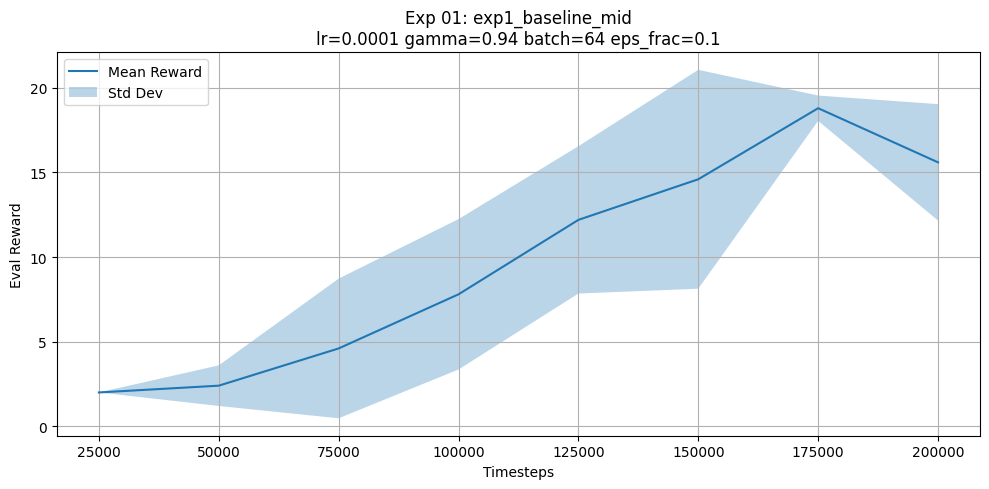

  Plot saved  -> /kaggle/working/kerie/runs/exp1_baseline_mid/reward_plot.png
  CSV saved   -> /kaggle/working/kerie/runs/exp1_baseline_mid/results.csv

  Experiment 02: exp2_lr_bump
  Notes: Slight lr bump — faster policy updates
  lr=0.0002  gamma=0.94  batch=64
  eps_start=1.0  eps_end=0.05  eps_frac=0.1
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /kaggle/working/kerie/runs/exp2_lr_bump/tensorboard/exp2_lr_bump_1


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7886d2a946e0> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7886d2b67b60>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.995    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 281      |
|    time_elapsed     | 0        |
|    total_timesteps  | 114      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.991    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 291      |
|    time_elapsed     | 0        |
|    total_timesteps  | 193      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.987    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 296      |
|    time_elapsed     | 0        |
|    total_timesteps  | 273      |
----------------------------------
----------------------------------
| rollout/          

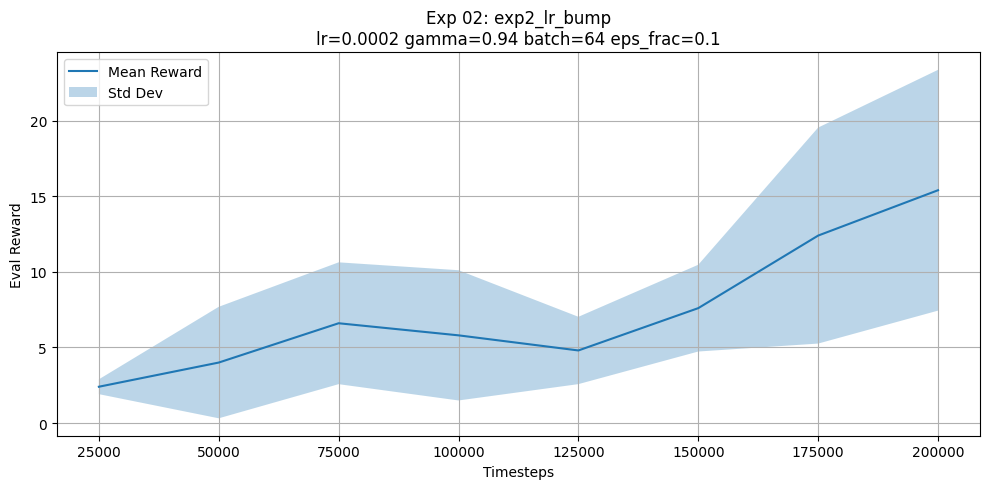

  Plot saved  -> /kaggle/working/kerie/runs/exp2_lr_bump/reward_plot.png
  CSV saved   -> /kaggle/working/kerie/runs/exp2_lr_bump/results.csv

  Experiment 03: exp3_higher_gamma
  Notes: Higher gamma — values future rewards more
  lr=0.0001  gamma=0.95  batch=64
  eps_start=1.0  eps_end=0.05  eps_frac=0.1
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /kaggle/working/kerie/runs/exp3_higher_gamma/tensorboard/exp3_higher_gamma_1


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7886d2766180> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7886d2930ad0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.995    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 293      |
|    time_elapsed     | 0        |
|    total_timesteps  | 107      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.988    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 308      |
|    time_elapsed     | 0        |
|    total_timesteps  | 243      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.985    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 303      |
|    time_elapsed     | 1        |
|    total_timesteps  | 319      |
----------------------------------
----------------------------------
| rollout/          

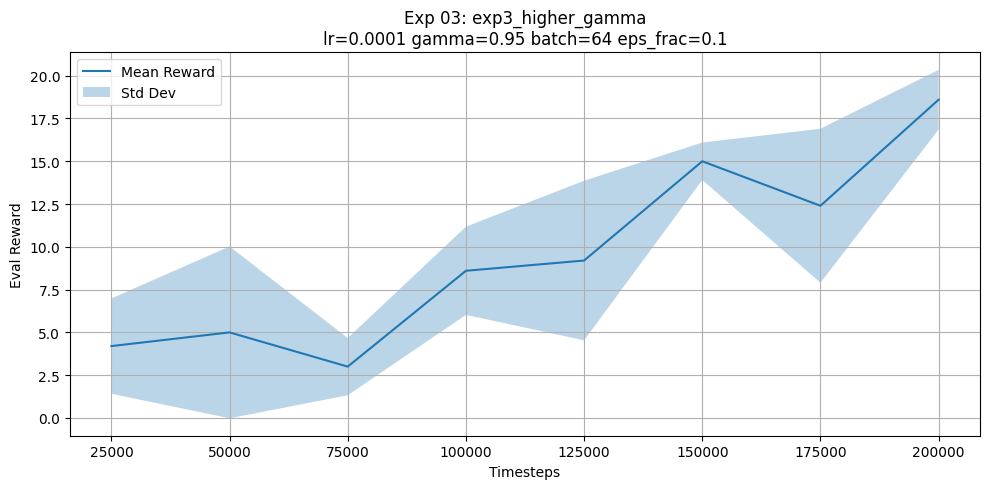

  Plot saved  -> /kaggle/working/kerie/runs/exp3_higher_gamma/reward_plot.png
  CSV saved   -> /kaggle/working/kerie/runs/exp3_higher_gamma/results.csv

  Experiment 04: exp4_lower_eps_start
  Notes: Lower eps_start — less initial randomness
  lr=0.0003  gamma=0.94  batch=64
  eps_start=0.9  eps_end=0.05  eps_frac=0.1
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /kaggle/working/kerie/runs/exp4_lower_eps_start/tensorboard/exp4_lower_eps_start_1


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7886d278ed20> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7886d2786420>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.895    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 284      |
|    time_elapsed     | 0        |
|    total_timesteps  | 109      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.891    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 293      |
|    time_elapsed     | 0        |
|    total_timesteps  | 205      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.887    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 299      |
|    time_elapsed     | 1        |
|    total_timesteps  | 301      |
----------------------------------
----------------------------------
| rollout/          

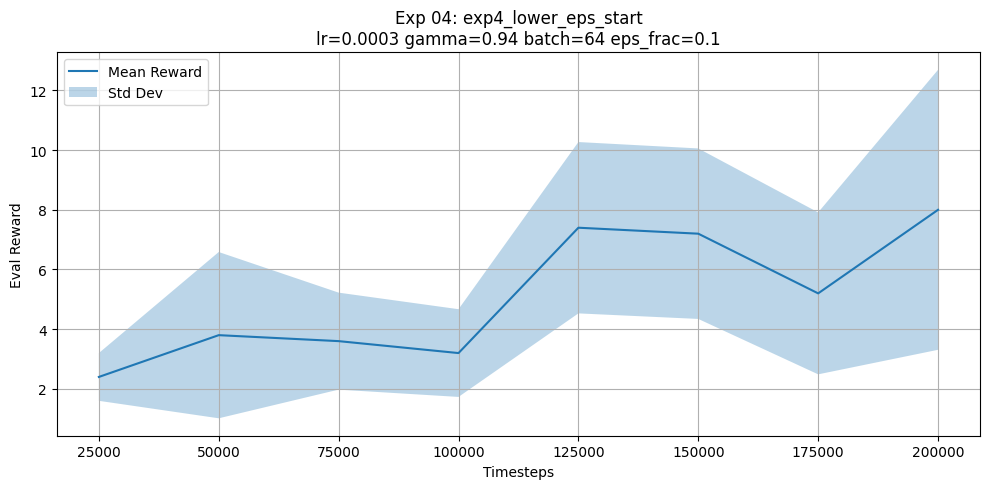

  Plot saved  -> /kaggle/working/kerie/runs/exp4_lower_eps_start/reward_plot.png
  CSV saved   -> /kaggle/working/kerie/runs/exp4_lower_eps_start/results.csv

  Experiment 05: exp5_lower_eps_end
  Notes: Lower eps_end — more greedy late stage
  lr=0.0001  gamma=0.96  batch=64
  eps_start=1.0  eps_end=0.02  eps_frac=0.1
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /kaggle/working/kerie/runs/exp5_lower_eps_end/tensorboard/exp5_lower_eps_end_1


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7886d2781430> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7886d27878c0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.994    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 255      |
|    time_elapsed     | 0        |
|    total_timesteps  | 123      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.989    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 256      |
|    time_elapsed     | 0        |
|    total_timesteps  | 220      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.983    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 265      |
|    time_elapsed     | 1        |
|    total_timesteps  | 346      |
----------------------------------
----------------------------------
| rollout/          

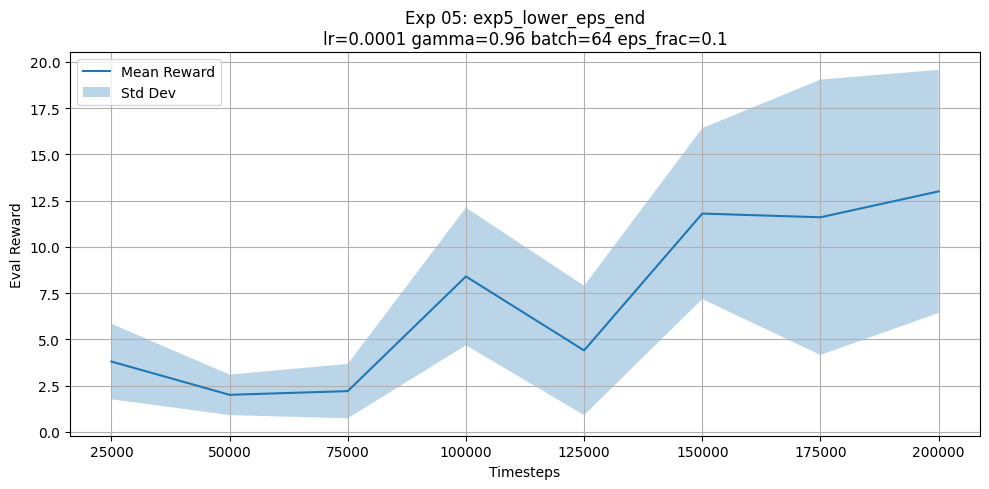

  Plot saved  -> /kaggle/working/kerie/runs/exp5_lower_eps_end/reward_plot.png
  CSV saved   -> /kaggle/working/kerie/runs/exp5_lower_eps_end/results.csv

  Experiment 06: exp6_faster_decay
  Notes: Faster decay — earlier shift to exploit
  lr=0.0002  gamma=0.95  batch=64
  eps_start=1.0  eps_end=0.05  eps_frac=0.05
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /kaggle/working/kerie/runs/exp6_faster_decay/tensorboard/exp6_faster_decay_1


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7886d28faba0> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7886d2857920>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.991    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 232      |
|    time_elapsed     | 0        |
|    total_timesteps  | 91       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.981    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 246      |
|    time_elapsed     | 0        |
|    total_timesteps  | 202      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.971    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 251      |
|    time_elapsed     | 1        |
|    total_timesteps  | 308      |
----------------------------------
----------------------------------
| rollout/          

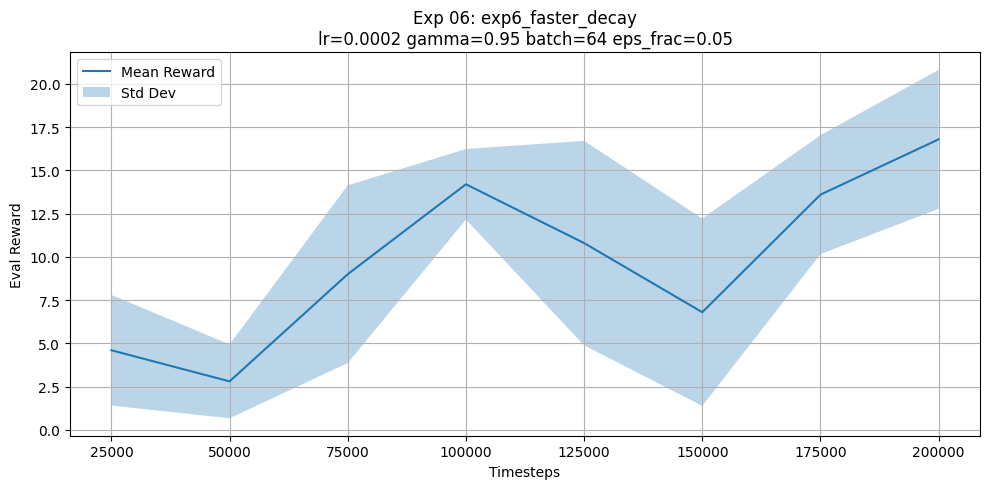

  Plot saved  -> /kaggle/working/kerie/runs/exp6_faster_decay/reward_plot.png
  CSV saved   -> /kaggle/working/kerie/runs/exp6_faster_decay/results.csv

  Experiment 07: exp7_slower_decay
  Notes: Slower decay — prolonged exploration
  lr=0.0001  gamma=0.94  batch=64
  eps_start=1.0  eps_end=0.05  eps_frac=0.25
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /kaggle/working/kerie/runs/exp7_slower_decay/tensorboard/exp7_slower_decay_1


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7886d278b2f0> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7886d2a06420>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.998    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 224      |
|    time_elapsed     | 0        |
|    total_timesteps  | 99       |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.997    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 228      |
|    time_elapsed     | 0        |
|    total_timesteps  | 182      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.995    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 235      |
|    time_elapsed     | 1        |
|    total_timesteps  | 286      |
----------------------------------
----------------------------------
| rollout/          

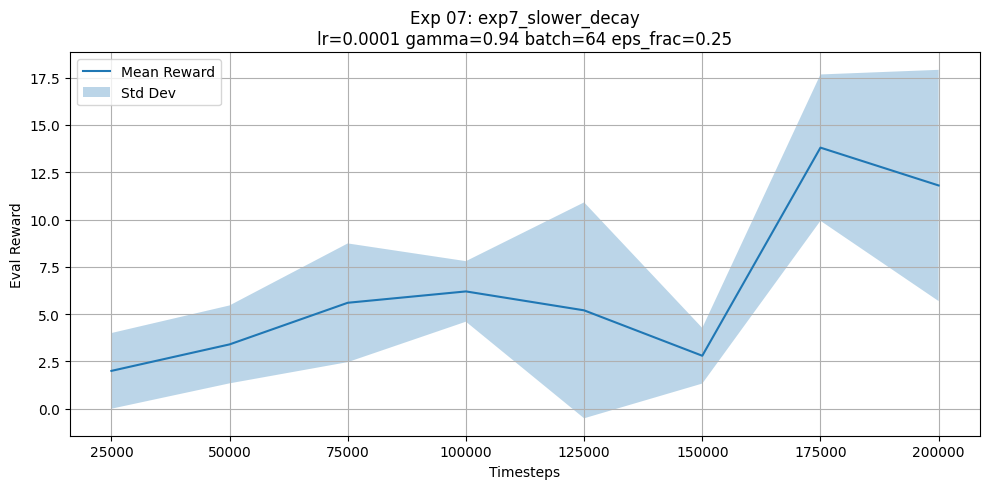

  Plot saved  -> /kaggle/working/kerie/runs/exp7_slower_decay/reward_plot.png
  CSV saved   -> /kaggle/working/kerie/runs/exp7_slower_decay/results.csv

  Experiment 08: exp8_mixed_mid
  Notes: Mixed mid — combined moderate changes
  lr=0.0004  gamma=0.95  batch=64
  eps_start=0.9  eps_end=0.02  eps_frac=0.1
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /kaggle/working/kerie/runs/exp8_mixed_mid/tensorboard/exp8_mixed_mid_1


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7886d2aa45f0> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7886d2a0c350>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.892    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 260      |
|    time_elapsed     | 0        |
|    total_timesteps  | 175      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.889    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 256      |
|    time_elapsed     | 0        |
|    total_timesteps  | 246      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.886    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 253      |
|    time_elapsed     | 1        |
|    total_timesteps  | 329      |
----------------------------------
----------------------------------
| rollout/          

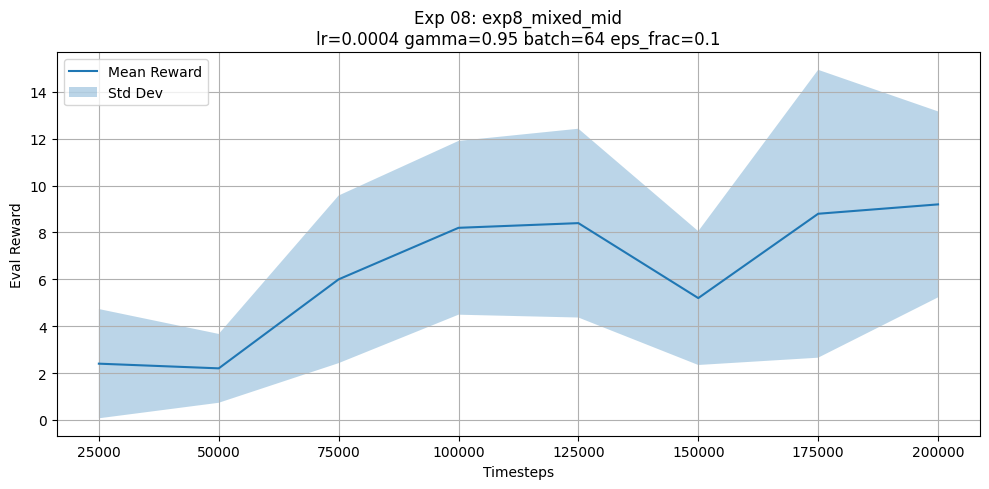

  Plot saved  -> /kaggle/working/kerie/runs/exp8_mixed_mid/reward_plot.png
  CSV saved   -> /kaggle/working/kerie/runs/exp8_mixed_mid/results.csv

  Experiment 09: exp9_moderate_decay_high_gamma
  Notes: Moderate decay with higher gamma
  lr=0.0003  gamma=0.96  batch=64
  eps_start=1.0  eps_end=0.05  eps_frac=0.15
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /kaggle/working/kerie/runs/exp9_moderate_decay_high_gamma/tensorboard/exp9_moderate_decay_high_gamma_1


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 5.65GB > 2.64GB
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:418: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7886d27e7620> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7886d25c1070>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.996    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 227      |
|    time_elapsed     | 0        |
|    total_timesteps  | 142      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.993    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 226      |
|    time_elapsed     | 0        |
|    total_timesteps  | 226      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.99     |
| time/               |          |
|    episodes         | 12       |
|    fps              | 224      |
|    time_elapsed     | 1        |
|    total_timesteps  | 321      |
----------------------------------
----------------------------------
| rollout/          

In [ ]:
# ── 6. Run all 10 experiments ────────────────────────────────────
# Exps 1-9 → 200k steps each | Exp 10 → 1M steps
# Finished experiments are skipped automatically on re-run.

results = {}
for exp_id in EXPERIMENTS:
    timesteps = TIMESTEPS_FULL if exp_id == 10 else TIMESTEPS_DEFAULT
    path = run_experiment(exp_id, total_timesteps=timesteps)
    results[exp_id] = path

print('ALL EXPERIMENTS COMPLETE')
for exp_id, path in results.items():
    print(f'  Exp {exp_id:02d}: {path}')
print('='*60)

In [ ]:
# â”€â”€ 7. Summary comparison plot (all experiments) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
plt.figure(figsize=(14, 6))

for exp_id, cfg in EXPERIMENTS.items():
    eval_npz = os.path.join(OUTPUT_DIR, cfg['name'], 'eval', 'evaluations.npz')
    if not os.path.isfile(eval_npz):
        continue
    data         = np.load(eval_npz)
    timesteps    = data['timesteps']
    mean_rewards = data['results'].mean(axis=1)
    plt.plot(timesteps, mean_rewards, label=f"Exp{exp_id:02d} lr={cfg['learning_rate']} Î³={cfg['gamma']}")

plt.xlabel('Timesteps')
plt.ylabel('Mean Eval Reward')
plt.title('All 10 Experiments â€” Mid-Range (Member 2, CnnPolicy)')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
summary_path = os.path.join(OUTPUT_DIR, 'summary_all_experiments.png')
plt.savefig(summary_path, dpi=150)
plt.show()
print(f'Summary plot saved -> {summary_path}')

In [ ]:
# â”€â”€ 8. Summary table (best reward per experiment) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print(f"{'Exp':<5} {'Name':<40} {'Best Reward':>12} {'Final Reward':>13}")
print('-' * 75)

summary_rows = []
for exp_id, cfg in EXPERIMENTS.items():
    eval_npz = os.path.join(OUTPUT_DIR, cfg['name'], 'eval', 'evaluations.npz')
    if not os.path.isfile(eval_npz):
        print(f"{exp_id:<5} {cfg['name']:<40} {'NOT DONE':>12}")
        continue
    data         = np.load(eval_npz)
    mean_rewards = data['results'].mean(axis=1)
    best_reward  = mean_rewards.max()
    final_reward = mean_rewards[-1]
    print(f"{exp_id:<5} {cfg['name']:<40} {best_reward:>12.1f} {final_reward:>13.1f}")
    summary_rows.append([exp_id, cfg['name'], cfg['learning_rate'], cfg['gamma'],
                         cfg['batch_size'], cfg['exploration_initial_eps'],
                         cfg['exploration_final_eps'], cfg['exploration_fraction'],
                         f'{best_reward:.1f}', f'{final_reward:.1f}', cfg['notes']])

# Save summary CSV
summary_csv = os.path.join(OUTPUT_DIR, 'summary_table.csv')
with open(summary_csv, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['exp', 'name', 'lr', 'gamma', 'batch', 'eps_start', 'eps_end', 'eps_frac', 'best_reward', 'final_reward', 'notes'])
    writer.writerows(summary_rows)
print(f'\nSummary CSV saved -> {summary_csv}')
print('\nDownload all outputs from the Output tab on the right ->')